# 00 — Environment and Data Validation

This notebook verifies the development environment and loads the Marmousi2
P-wave velocity model for visual inspection.

**Execution order:**
1. Verify packages and src modules
2. Load and visualize velocity model
3. Save config.json for downstream notebooks

## 1. Environment

In [1]:
import sys
import os
import importlib.metadata

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root : {project_root}')
print(f'Python       : {sys.version}')

Project root : /home/rafae/projetos/seismic-velocity-picking
Python       : 3.12.3 (main, May 14 2026, 21:15:07) [GCC 15.2.0]


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import segyio

print('=== Package versions ===')
print(f'NumPy      : {np.__version__}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'SciPy      : {scipy.__version__}')
print(f'Segyio     : {importlib.metadata.version("segyio")}')

=== Package versions ===
NumPy      : 2.4.3
Matplotlib : 3.10.9
SciPy      : 1.17.1
Segyio     : 1.9.14


In [3]:
from src.seismic.io        import load_bin, load_marmousi2_velocity
from src.seismic.cdp       import sort_cdp_gathers, cdp_coverage
from src.seismic.nmo       import apply_nmo, stack_gather
from src.seismic.semblance import compute_semblance
from src.optimizers.base   import BaseOptimizer

print('All src modules imported successfully.')

All src modules imported successfully.


## 2. Data paths

In [4]:
MARMOUSI_DIR = os.path.join(project_root, 'data', 'models', 'marmousi2')
VELOCITY_BIN = os.path.join(MARMOUSI_DIR, 'MODEL_P-WAVE_VELOCITY_1.25m.bin')

print('=== File check ===')
exists  = os.path.exists(VELOCITY_BIN)
size_mb = os.path.getsize(VELOCITY_BIN) / 1024**2 if exists else 0
status  = f'OK ({size_mb:.1f} MB)' if exists else 'NOT FOUND'
print(f'  Velocity model (bin): {status}')

if not exists:
    print()
    print('WARNING: file not found.')
    print('Download from:')
    print('  https://www.geoazur.fr/WIND/pub/nfs/FWI-DATA/GEOMODELS/MarmousiII/MODEL_P-WAVE_VELOCITY_1.25m.bin')
    print(f'Place it in: {MARMOUSI_DIR}')

=== File check ===
  Velocity model (bin): OK (145.3 MB)


## 3. Load and visualize velocity model

In [5]:
vel, info = load_marmousi2_velocity(MARMOUSI_DIR)

print()
print(f'Shape  : {vel.shape}  (n_horizontal x n_vertical)')
print(f'Vel min: {info["val_min"]:.1f} m/s')
print(f'Vel max: {info["val_max"]:.1f} m/s')
print(f'X ext  : {info["x_max_km"]:.2f} km')
print(f'Z ext  : {info["z_max_km"]:.2f} km')

Loaded : MODEL_P-WAVE_VELOCITY_1.25m.bin
  Shape    : (13601, 2801)  (n2 x n1)
  X extent : 17.00 km
  Z extent : 3.50 km
  Min      : 1028.0
  Max      : 4700.0
  Mean     : 2671.8

Shape  : (13601, 2801)  (n_horizontal x n_vertical)
Vel min: 1028.0 m/s
Vel max: 4700.0 m/s
X ext  : 17.00 km
Z ext  : 3.50 km


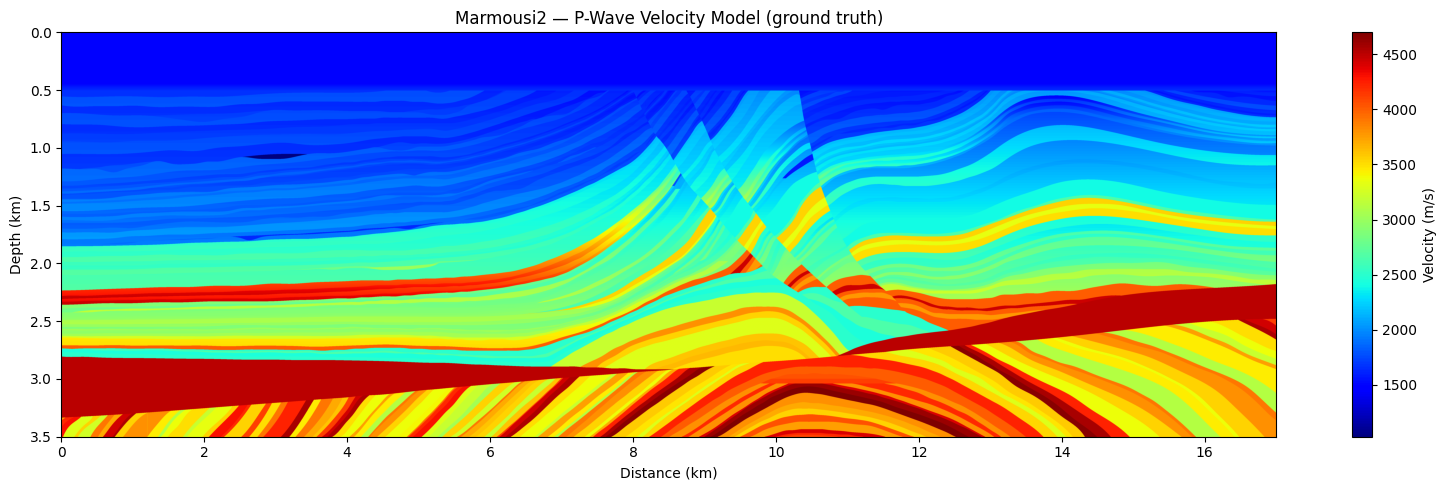

Figure saved to results/figures/00_velocity_model.png


In [6]:
os.makedirs(os.path.join(project_root, 'results', 'figures'), exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    vel.T,
    aspect='auto',
    cmap='jet',
    extent=[0, info['x_max_km'], info['z_max_km'], 0]
)
plt.colorbar(im, ax=ax, label='Velocity (m/s)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Depth (km)')
ax.set_title('Marmousi2 — P-Wave Velocity Model (ground truth)')
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures', '00_velocity_model.png'),
    dpi=150
)
plt.show()
print('Figure saved to results/figures/00_velocity_model.png')

## 4. Save config.json

In [7]:
import json

config = {
    'project_root': project_root,
    'paths': {
        'marmousi_dir': MARMOUSI_DIR,
        'velocity_bin': VELOCITY_BIN,
    },
    'marmousi2': {
        'n1':        info['n1'],
        'n2':        info['n2'],
        'spacing_m': info['spacing_m'],
        'x_max_km':  info['x_max_km'],
        'z_max_km':  info['z_max_km'],
        'vel_min':   info['val_min'],
        'vel_max':   info['val_max'],
        'vel_mean':  info['val_mean'],
    },
}

os.makedirs(os.path.join(project_root, 'results'), exist_ok=True)
config_path = os.path.join(project_root, 'results', 'config.json')

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved to: {config_path}')
print()
print(json.dumps(config, indent=2))

Config saved to: /home/rafae/projetos/seismic-velocity-picking/results/config.json

{
  "project_root": "/home/rafae/projetos/seismic-velocity-picking",
  "paths": {
    "marmousi_dir": "/home/rafae/projetos/seismic-velocity-picking/data/models/marmousi2",
    "velocity_bin": "/home/rafae/projetos/seismic-velocity-picking/data/models/marmousi2/MODEL_P-WAVE_VELOCITY_1.25m.bin"
  },
  "marmousi2": {
    "n1": 2801,
    "n2": 13601,
    "spacing_m": 1.25,
    "x_max_km": 17.00125,
    "z_max_km": 3.50125,
    "vel_min": 1028.0,
    "vel_max": 4700.0,
    "vel_mean": 2671.79345703125
  }
}


## 5. Summary

If all cells above ran without errors, the environment is ready.

**What was validated:**
- All required packages installed
- All src modules importable
- Marmousi2 binary velocity model loaded and visualized
- config.json saved for downstream notebooks

**Next notebooks:**
- `01_cdp_gathers.ipynb` — organize synthetic data into CDP gathers
- `02_semblance.ipynb`   — compute semblance and validate visually
- `03_picking_baseline.ipynb` — extract ground truth picks from velocity model